# protGPS on ClinVar: condensate localization variant effects

Loads the merged wild-type vs. mutant protGPS predictions (`clinvar_protgps_deltas_rbp.tsv`, built by `../12_variant_effect_prediction/localization_condensate/`) and does a first-pass sanity check + exploration.

**Data file is not checked into git** (766MB) — regenerate it by running the pipeline in `12_variant_effect_prediction/localization_condensate/`, specifically the delta-merge step, or pull `clinvar_protgps_deltas_rbp.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

**RBP-only version.** Filtered to the 2,215-gene RNA-binding-protein list in `../12_variant_effect_prediction/rbp_filter/rbp_gene_symbols.txt` (union of a classic-RNA-binding-domain list and RBP2GO's high-confidence human RBP dataset -- see that folder's README for the full method). The genome-wide version of this notebook is `protgps_clinvar_exploration.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

COMPARTMENTS = [
    "NUCLEAR_SPECKLE", "P-BODY", "PML-BDOY", "POST_SYNAPTIC_DENSITY",
    "STRESS_GRANULE", "CHROMOSOME", "NUCLEOLUS", "NUCLEAR_PORE_COMPLEX",
    "CAJAL_BODY", "RNA_GRANULE", "CELL_JUNCTION", "TRANSCRIPTIONAL",
]

## Load data

In [2]:
df = pd.read_csv("clinvar_protgps_deltas_rbp.tsv", sep="\t")
print(f"{len(df):,} variant rows")
df.head()

363,750 variant rows


,VariationID,GeneID,GeneSymbol,accession,category,WT_NUCLEAR_SPECKLE,WT_P-BODY,WT_PML-BDOY,WT_POST_SYNAPTIC_DENSITY,WT_STRESS_GRANULE,...,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
0,41,284403,WDR62,NM_001083961.2,missense,0.0000,0.0711,0.0013,0.0,0.6223,...,0.0008,0.0000,-0.1131,-0.0012,0.0000,0.0121,0.0000,0.0000,0.0003,0.0
1,42,284403,WDR62,NM_001083961.2,missense,0.0000,0.0711,0.0013,0.0,0.6223,...,0.0002,0.0000,-0.0431,0.0039,0.0000,0.0047,0.0000,0.0000,0.0000,0.0
2,43,284403,WDR62,NM_001083961.2,nonsense,0.0000,0.0711,0.0013,0.0,0.6223,...,0.0084,0.3641,-0.6222,-0.0106,0.0128,-0.0211,0.0000,0.0000,0.0000,0.0
3,203,79650,USB1,NM_024598.4,missense,0.0000,0.0014,0.0005,0.0,0.0005,...,0.0001,0.0000,-0.0002,-0.0030,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
4,268,282996,RBM20,NM_001134363.3,missense,0.0005,0.7364,0.0193,0.0,0.7212,...,0.0005,0.0000,-0.0096,-0.0001,0.0002,0.0000,0.0001,-0.0041,0.0000,0.0


## Sanity check: known condensate marker genes (wild-type scores)

Checking a handful of textbook condensate proteins against their well-established localization. `COIL`/`FUS`/`G3BP1`/`TARDBP` matched expectations exactly when checked manually; `NPM1` (canonically nucleolar) did not — protGPS scored it as stress-granule-like instead. Worth keeping in mind as a known model limitation, not a pipeline bug (the WT sequence was independently verified correct).

In [3]:
known_genes = {
    "COIL": ("NM_004645.3", "CAJAL_BODY"),
    "FUS": ("NM_004960.4", "STRESS_GRANULE"),
    "G3BP1": ("NM_005754.3", "STRESS_GRANULE"),
    "TARDBP": ("NM_007375.4", "STRESS_GRANULE"),
}
# NPM1 (used in the genome-wide version) isn't in the RBP gene list, dropped here.

wt_cols = [f"WT_{c}" for c in COMPARTMENTS]
for gene, (acc, expected) in known_genes.items():
    rows = df[df["accession"] == acc]
    if rows.empty:
        print(f"{gene} ({acc}): no variant rows in this table (no missense/etc. built for it)")
        continue
    wt_scores = rows.iloc[0][wt_cols]
    top = wt_scores.astype(float).idxmax().replace("WT_", "")
    top_score = wt_scores.astype(float).max()
    match = "OK" if top == expected else "MISMATCH"
    print(f"{gene:8s} ({acc}): top={top:22s} ({top_score:.3f})  expected={expected:15s}  [{match}]")

COIL     (NM_004645.3): top=CAJAL_BODY             (0.992)  expected=CAJAL_BODY       [OK]
FUS      (NM_004960.4): top=STRESS_GRANULE         (0.874)  expected=STRESS_GRANULE   [OK]
G3BP1    (NM_005754.3): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]
TARDBP   (NM_007375.4): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]


## Wild-type score distributions

Most proteins should score near 0 for most compartments (condensate-specific localization is the exception, not the rule).

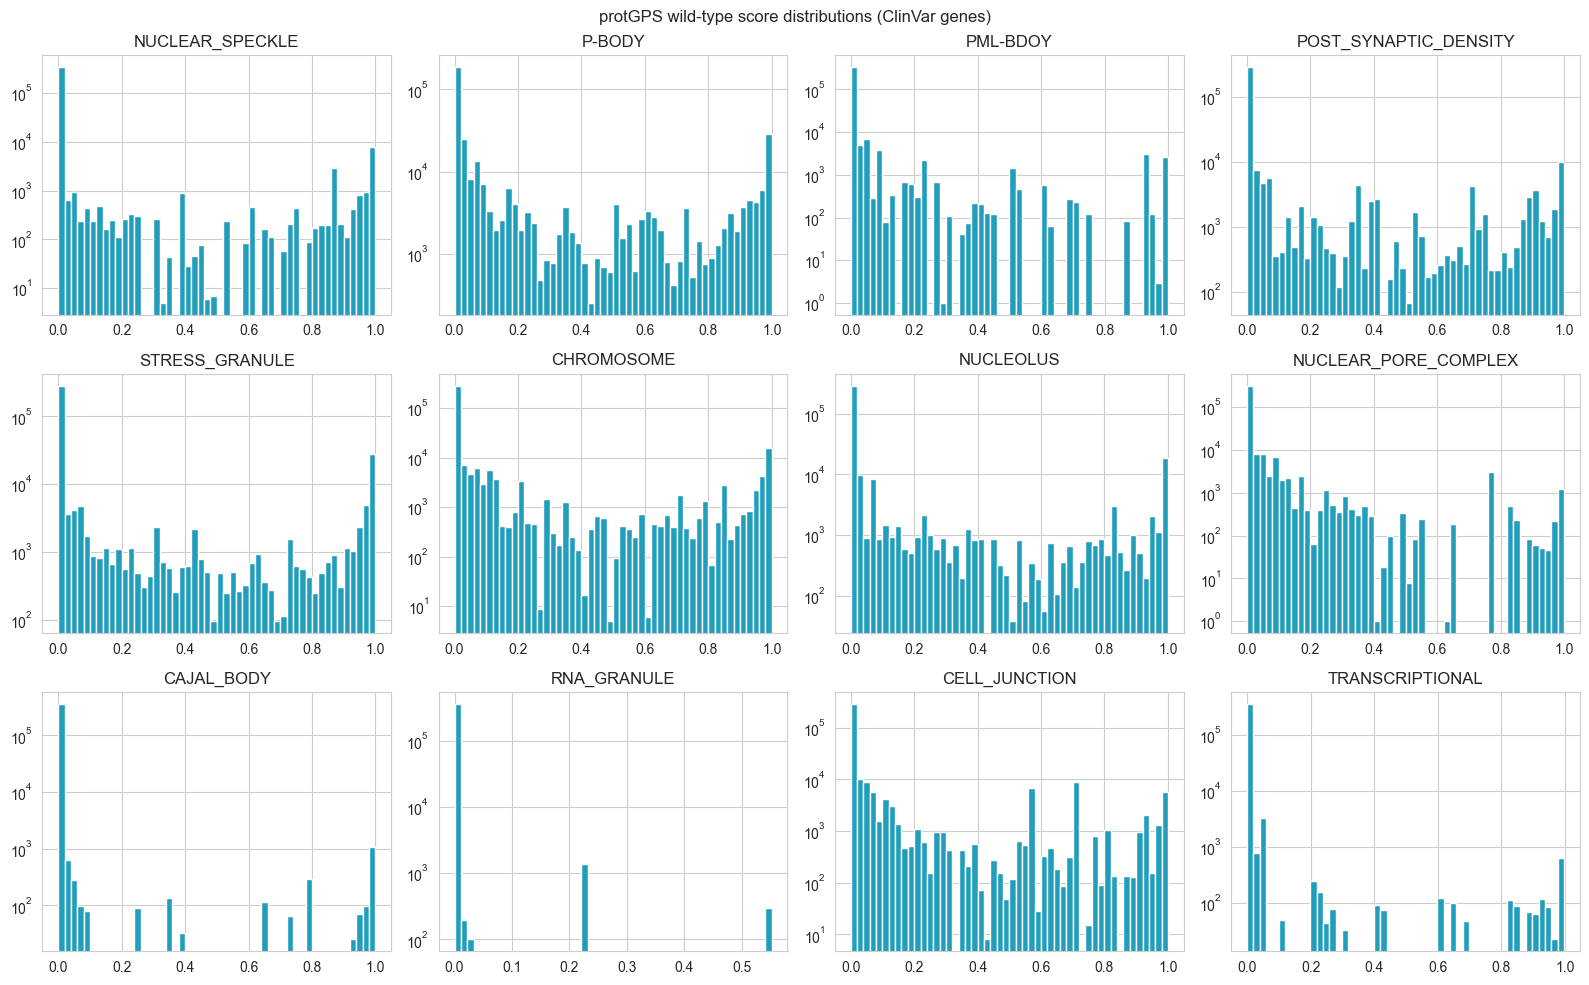

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"WT_{c}"], bins=50, color="#219ebc")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS wild-type score distributions (ClinVar genes)")
fig.tight_layout()
plt.show()

## Variant effect (delta) distributions

`DELTA = mutant_score - WT_score`. Most variants should have near-zero delta (no predicted change in condensate association); the tails are the interesting cases.

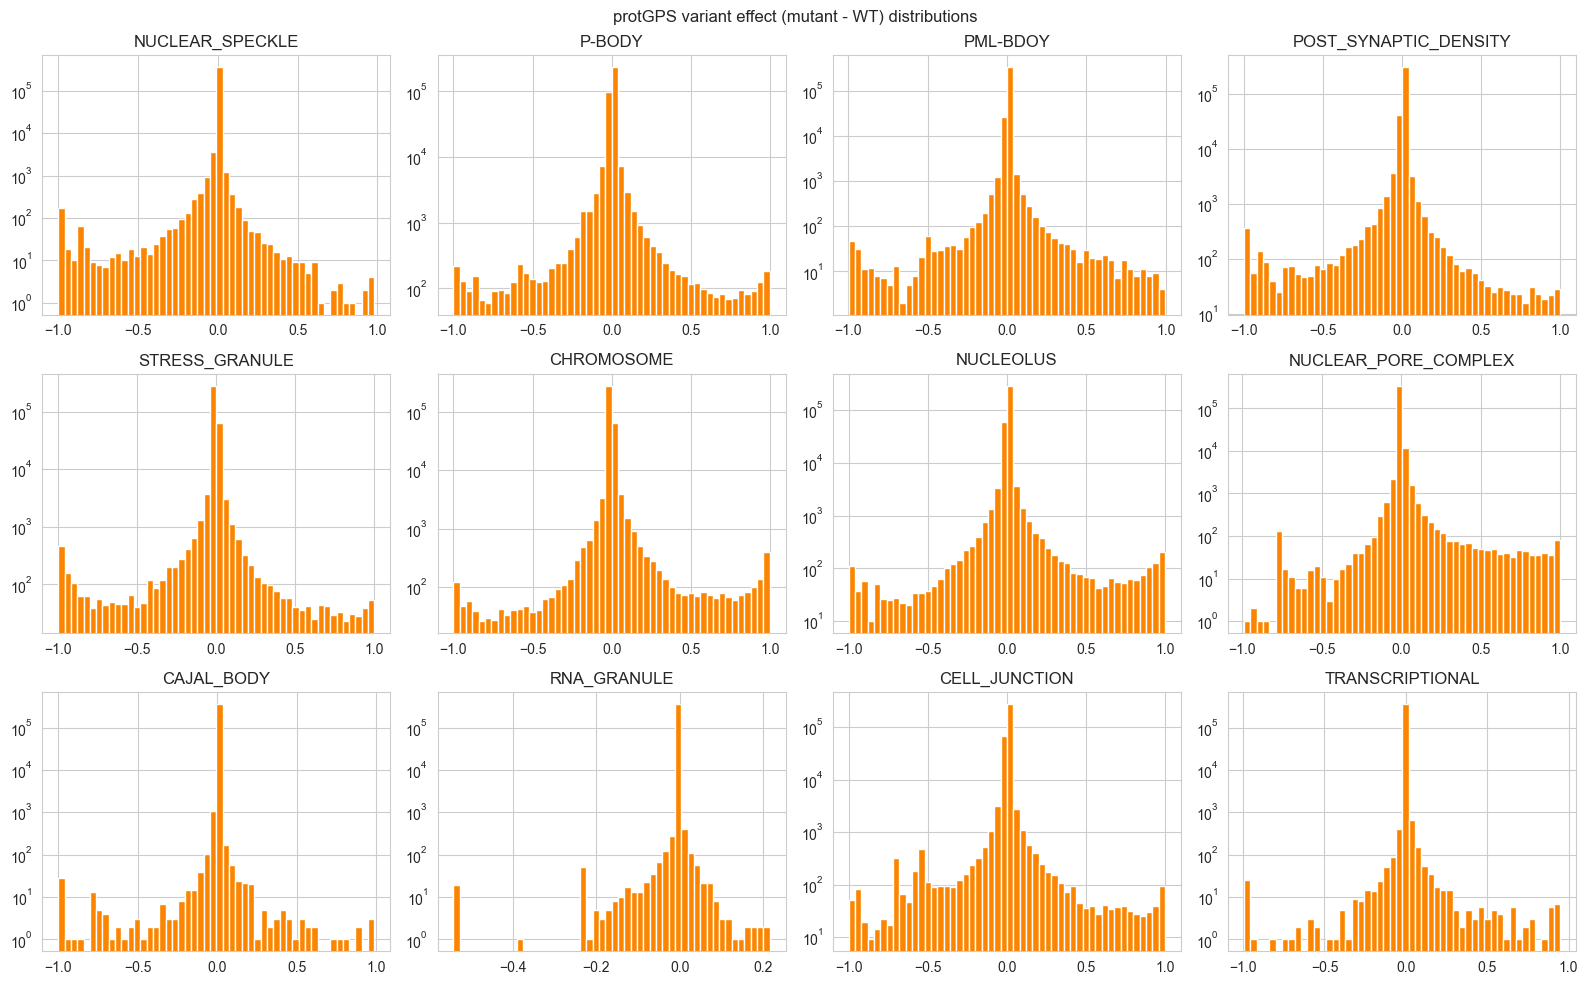

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"DELTA_{c}"], bins=50, color="#fb8500")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS variant effect (mutant - WT) distributions")
fig.tight_layout()
plt.show()

## Variants with the largest predicted condensate-localization change

Ranked by the single largest absolute delta across any compartment — these are the variants protGPS predicts most strongly alter condensate association.

In [6]:
delta_cols = [f"DELTA_{c}" for c in COMPARTMENTS]
max_abs_delta = df[delta_cols].abs().max(axis=1)
top_variants = df.loc[max_abs_delta.sort_values(ascending=False).index[:25]]
top_variants[["VariationID", "GeneSymbol", "category", "accession"] + delta_cols].head(25)

,VariationID,GeneSymbol,category,accession,DELTA_NUCLEAR_SPECKLE,DELTA_P-BODY,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
185990,2880488,RIGI,nonsense,NM_014314.4,0.0000,0.9542,0.0001,0.0000,0.1943,0.0000,0.0000,0.2638,0.0000,0.0,-1.0000,0.0000
249521,3599897,GANAB,nonsense,NM_198334.3,0.0000,0.0000,0.0000,-0.7389,0.0000,1.0000,0.0002,0.0000,0.0000,0.0,0.0002,0.0000
249524,3599900,GANAB,nonsense,NM_198334.3,0.0000,0.0000,0.0000,-0.7389,0.0000,1.0000,0.0000,0.0013,0.0000,0.0,0.0013,0.0000
253117,3654541,RIGI,nonsense,NM_014314.4,0.0000,0.0002,0.0201,0.0000,0.0255,0.0157,0.0000,0.3063,0.0000,0.0,-1.0000,0.0000
83277,1511985,RIGI,nonsense,NM_014314.4,0.0000,0.0000,0.0013,0.0089,0.0000,0.0000,0.0000,0.0009,0.0000,0.0,-1.0000,0.0000
119641,2034289,RIGI,nonsense,NM_014314.4,0.0000,0.0070,0.0287,0.0000,0.0036,0.0023,0.0000,0.0264,0.0000,0.0,-1.0000,0.0000
228701,3375160,RIGI,nonsense,NM_014314.4,0.0000,0.0023,0.0000,0.0000,0.0000,0.9297,0.2752,0.0002,0.0000,0.0,-1.0000,0.0000
178867,2725054,RIGI,nonsense,NM_014314.4,0.0000,0.0000,0.0015,0.0006,0.0399,0.0613,0.0000,0.1455,0.0000,0.0,-1.0000,0.0000
349454,4716774,EPHB4,nonsense,NM_004444.5,0.0000,-0.0745,-0.0001,0.0000,0.0000,1.0000,0.0000,0.3934,0.0000,0.0,-0.9931,0.0000
119190,2022058,LRPPRC,nonsense,NM_133259.4,0.0000,-0.0003,0.0000,-0.9947,0.0000,1.0000,0.0007,-0.0062,0.0000,0.0,0.0000,0.0000


## How many variants change predicted condensate localization?

protGPS gives a continuous score per compartment rather than a single predicted label, so "changed" here means the variant's largest absolute delta across the 12 compartments is >= 0.5 (the same high-confidence cutoff used elsewhere in this project). Counts, then the fraction changed by variant category.

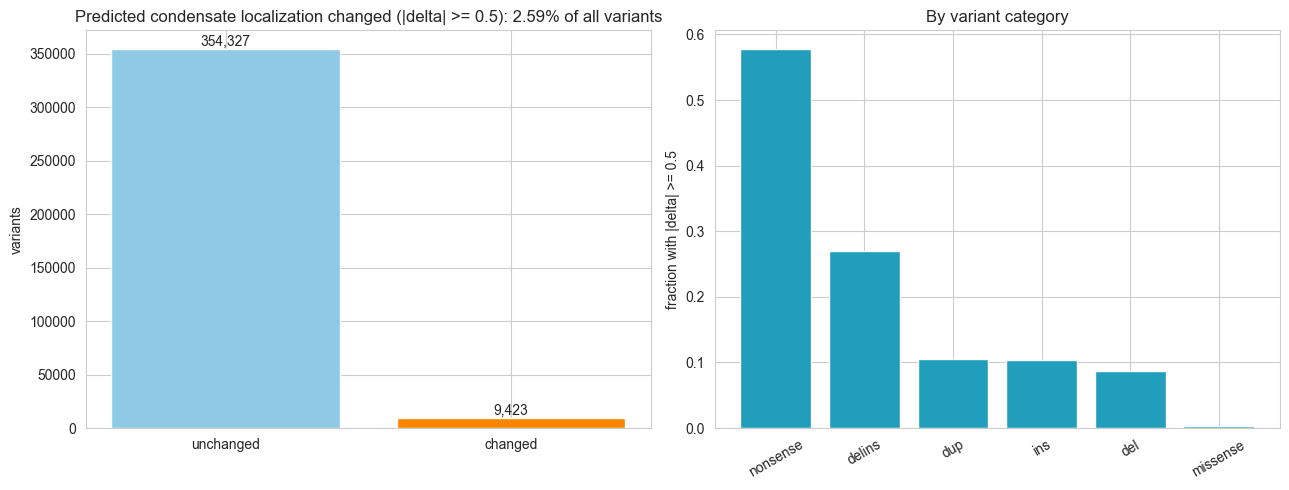

In [7]:
delta_cols = [f"DELTA_{c}" for c in COMPARTMENTS]
max_abs_delta = df[delta_cols].abs().max(axis=1)
changed = max_abs_delta >= 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = changed.map({False: "unchanged", True: "changed"}).value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[4]])
axes[0].set_ylabel("variants")
axes[0].set_title(f"Predicted condensate localization changed (|delta| >= 0.5): {changed.mean():.2%} of all variants")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

by_cat = pd.Series(changed).groupby(df["category"]).mean().sort_values(ascending=False)
axes[1].bar(by_cat.index, by_cat.values, color=PALETTE[1])
axes[1].set_ylabel("fraction with |delta| >= 0.5")
axes[1].set_title("By variant category")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

## Is a condensate-localization change more common among pathogenic variants?

Joins `ClinicalSignificance` from `clinvar_metadata_lookup_rbp.tsv`. If protGPS's predicted condensate shift is functionally meaningful, pathogenic variants should show it more often than benign ones.

                             n  frac_changed
ClinicalSignificance                        
Pathogenic                9469      0.476291
Likely pathogenic         5554      0.197515
Uncertain significance  301362      0.006753
Likely benign            13354      0.004493
Benign                    3475      0.005180


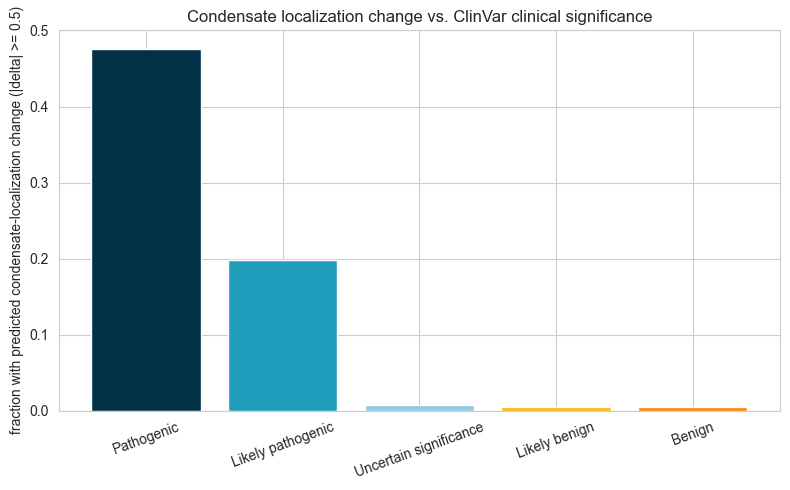

In [8]:
meta = pd.read_csv("clinvar_metadata_lookup_rbp.tsv", sep="\t", usecols=["VariationID", "ClinicalSignificance"]).drop_duplicates("VariationID")
m = df.merge(meta, on="VariationID", how="left")
m["max_abs_delta"] = max_abs_delta.values
m["changed"] = changed.values

groups = ["Pathogenic", "Likely pathogenic", "Uncertain significance", "Likely benign", "Benign"]
s = m[m["ClinicalSignificance"].isin(groups)]
summary = s.groupby("ClinicalSignificance")["changed"].agg(n="size", frac_changed="mean").loc[groups]
print(summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary.index, summary["frac_changed"], color=[PALETTE[2], PALETTE[1], PALETTE[0], PALETTE[3], PALETTE[4]])
ax.set_ylabel("fraction with predicted condensate-localization change (|delta| >= 0.5)")
ax.set_title("Condensate localization change vs. ClinVar clinical significance")
plt.xticks(rotation=20)
fig.tight_layout()
plt.show()